# PaySim EDA and Preprocessing

This notebook performs:
1. Exploratory Data Analysis (EDA) on the raw PaySim dataset
2. Preprocessing and feature engineering
3. Temporal train/test split and artifact export for downstream pipelines

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW_CSV = ROOT / 'data' / 'raw' / 'PaySim' / 'PS_20174392719_1491204439457_log.csv'
PROCESSED = ROOT / 'data' / 'processed' / 'paysim'
FEATURES = ROOT / 'data' / 'features' / 'paysim'
EDA_FIGURES = ROOT / 'notebooks' / 'eda_outputs' / 'figures'
EDA_TABLES = ROOT / 'notebooks' / 'eda_outputs' / 'tables'
REPORT_PATH = ROOT / 'notebooks' / 'eda_outputs' / 'PAYSIM_EDA_SUMMARY_REPORT.txt'

for path in [PROCESSED, FEATURES, EDA_FIGURES, EDA_TABLES]:
    path.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

print(f'ROOT: {ROOT}')
print(f'Raw dataset: {RAW_CSV}')

ROOT: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform
Raw dataset: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\data\raw\PaySim\PS_20174392719_1491204439457_log.csv


In [2]:
df = pd.read_csv(RAW_CSV)
print(f'Loaded PaySim shape: {df.shape}')
print('Columns:', df.columns.tolist())

overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_pct': (df.isna().mean() * 100).round(4),
    'n_unique': df.nunique(dropna=False)
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])
overview.to_csv(EDA_TABLES / 'paysim_column_overview.csv')

print('Top rows:')
display(df.head(5))
display(overview.head(20))

Loaded PaySim shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Top rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


,dtype,missing_pct,n_unique
nameOrig,str,0.0,6353307
amount,float64,0.0,5316900
oldbalanceDest,float64,0.0,3614697
newbalanceDest,float64,0.0,3555499
nameDest,str,0.0,2722362
newbalanceOrig,float64,0.0,2682586
oldbalanceOrg,float64,0.0,1845844
step,int64,0.0,743
type,str,0.0,5
isFraud,int64,0.0,2


In [3]:
# Core EDA tables
fraud_rate = df['isFraud'].mean()
flagged_rate = df['isFlaggedFraud'].mean()

type_distribution = df['type'].value_counts(dropna=False).rename_axis('type').reset_index(name='count')
type_distribution['pct'] = (type_distribution['count'] / len(df) * 100).round(4)
type_distribution.to_csv(EDA_TABLES / 'paysim_type_distribution.csv', index=False)

fraud_by_type = df.groupby('type', as_index=False).agg(
    total_transactions=('isFraud', 'size'),
    fraud_transactions=('isFraud', 'sum'),
    mean_amount=('amount', 'mean'),
    median_amount=('amount', 'median')
)
fraud_by_type['fraud_rate_pct'] = (fraud_by_type['fraud_transactions'] / fraud_by_type['total_transactions'] * 100).round(4)
fraud_by_type = fraud_by_type.sort_values('fraud_rate_pct', ascending=False)
fraud_by_type.to_csv(EDA_TABLES / 'paysim_fraud_by_type.csv', index=False)

step_fraud = df.groupby('step', as_index=False).agg(
    total_transactions=('isFraud', 'size'),
    fraud_transactions=('isFraud', 'sum'),
    avg_amount=('amount', 'mean')
)
step_fraud['fraud_rate_pct'] = (step_fraud['fraud_transactions'] / step_fraud['total_transactions'] * 100).round(6)
step_fraud.to_csv(EDA_TABLES / 'paysim_fraud_by_step.csv', index=False)

amount_quantiles = df['amount'].quantile([0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]).rename('amount_quantile').to_frame()
amount_quantiles.to_csv(EDA_TABLES / 'paysim_amount_quantiles.csv')

numeric_summary = df[['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].describe().T
numeric_summary.to_csv(EDA_TABLES / 'paysim_numeric_summary.csv')

print(f'Fraud rate: {fraud_rate:.4%}')
print(f'Flagged fraud rate: {flagged_rate:.6%}')
display(fraud_by_type)

Fraud rate: 0.1291%
Flagged fraud rate: 0.000251%


,type,total_transactions,fraud_transactions,mean_amount,median_amount,fraud_rate_pct
4,TRANSFER,532909,4097,910647.009645,486308.390,0.7688
1,CASH_OUT,2237500,4116,176273.964346,147072.185,0.1840
0,CASH_IN,1399284,0,168920.242004,143427.710,0.0000
2,DEBIT,41432,0,5483.665314,3048.990,0.0000
3,PAYMENT,2151495,0,13057.604660,9482.190,0.0000


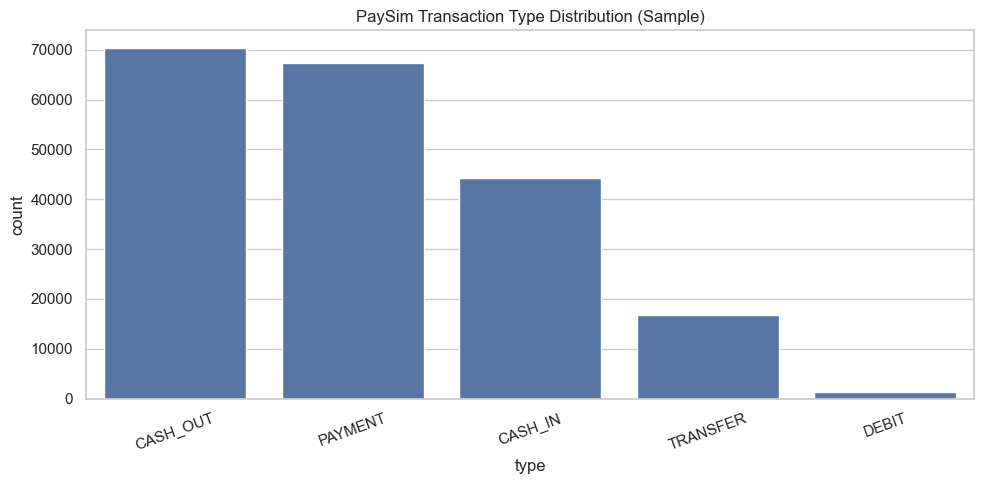

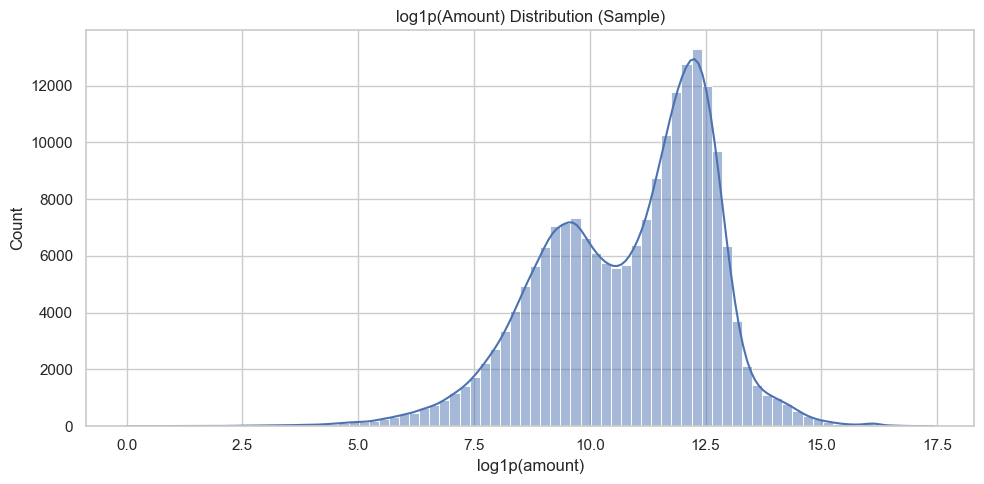

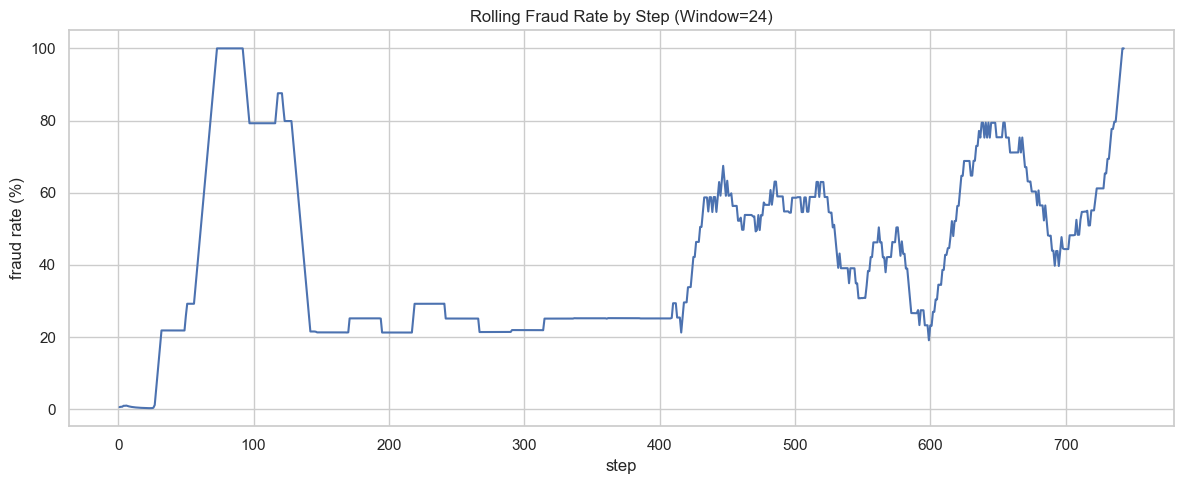

In [4]:
# Use a sample for plotting to keep plotting memory/time reasonable on very large data
sample_n = min(200_000, len(df))
plot_df = df.sample(sample_n, random_state=42)

plt.figure(figsize=(10, 5))
sns.countplot(data=plot_df, x='type', order=plot_df['type'].value_counts().index)
plt.title('PaySim Transaction Type Distribution (Sample)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(EDA_FIGURES / 'paysim_type_distribution.png', dpi=140)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(plot_df['amount']), bins=80, kde=True)
plt.title('log1p(Amount) Distribution (Sample)')
plt.xlabel('log1p(amount)')
plt.tight_layout()
plt.savefig(EDA_FIGURES / 'paysim_amount_log_distribution.png', dpi=140)
plt.show()

line_df = step_fraud.copy()
line_df['rolling_fraud_rate_pct'] = line_df['fraud_rate_pct'].rolling(24, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(line_df['step'], line_df['rolling_fraud_rate_pct'])
plt.title('Rolling Fraud Rate by Step (Window=24)')
plt.xlabel('step')
plt.ylabel('fraud rate (%)')
plt.tight_layout()
plt.savefig(EDA_FIGURES / 'paysim_rolling_fraud_rate.png', dpi=140)
plt.show()

In [5]:
summary_lines = [
    '=' * 72,
    'PAYSIM - EDA SUMMARY REPORT',
    '=' * 72,
    f'Total rows: {len(df):,}',
    f'Total columns: {df.shape[1]}',
    f'Fraud rate: {fraud_rate:.4%}',
    f'Flagged fraud rate: {flagged_rate:.6%}',
    '',
    'Top fraud-prone transaction types:',
]

for _, row in fraud_by_type.head(5).iterrows():
    summary_lines.append(
        f"  - {row['type']}: fraud_rate={row['fraud_rate_pct']:.4f}% | total={int(row['total_transactions']):,}"
    )

summary_lines.extend([
    '',
    'Recommended preprocessing applied in this notebook:',
    '  - Temporal split by step (80/20)',
    '  - Log transform for amount',
    '  - Balance consistency error features',
    '  - One-hot encoding for transaction type',
    '  - Median imputation for numeric columns',
    '=' * 72,
])

report_text = '\n'.join(summary_lines)
print(report_text)
REPORT_PATH.write_text(report_text, encoding='utf-8')
print(f'\nReport saved to: {REPORT_PATH}')

PAYSIM - EDA SUMMARY REPORT
Total rows: 6,362,620
Total columns: 11
Fraud rate: 0.1291%
Flagged fraud rate: 0.000251%

Top fraud-prone transaction types:
  - TRANSFER: fraud_rate=0.7688% | total=532,909
  - CASH_OUT: fraud_rate=0.1840% | total=2,237,500
  - CASH_IN: fraud_rate=0.0000% | total=1,399,284
  - DEBIT: fraud_rate=0.0000% | total=41,432
  - PAYMENT: fraud_rate=0.0000% | total=2,151,495

Recommended preprocessing applied in this notebook:
  - Temporal split by step (80/20)
  - Log transform for amount
  - Balance consistency error features
  - One-hot encoding for transaction type
  - Median imputation for numeric columns

Report saved to: d:\Mtech\Main project and Thesis\Federated-learning\ml-agentic-platform\notebooks\eda_outputs\PAYSIM_EDA_SUMMARY_REPORT.txt


In [6]:
proc = df.copy()

# Feature engineering
proc['log_amount'] = np.log1p(proc['amount'])
proc['orig_balance_error'] = (proc['oldbalanceOrg'] - proc['amount'] - proc['newbalanceOrig']).abs()
proc['dest_balance_error'] = (proc['oldbalanceDest'] + proc['amount'] - proc['newbalanceDest']).abs()

# Cyclical time features; step is hour-like in PaySim simulator
proc['step_sin'] = np.sin(2 * np.pi * proc['step'] / 24.0)
proc['step_cos'] = np.cos(2 * np.pi * proc['step'] / 24.0)

# Encode transaction type
type_ohe = pd.get_dummies(proc['type'], prefix='type', dtype='int8')
proc = pd.concat([proc.drop(columns=['type']), type_ohe], axis=1)

numeric_cols = proc.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    proc[col] = proc[col].fillna(proc[col].median())

# Temporal split to avoid leakage
split_step = int(proc['step'].quantile(0.80))
train = proc[proc['step'] <= split_step].copy()
test = proc[proc['step'] > split_step].copy()

# Build feature matrices
drop_feature_cols = ['isFraud', 'nameOrig', 'nameDest']
feature_cols = [c for c in train.columns if c not in drop_feature_cols]
X_train = train[feature_cols]
y_train = train['isFraud'].astype(int)
X_test = test[feature_cols]

print(f'Split step threshold: {split_step}')
print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'X_train: {X_train.shape} | y_train: {y_train.shape} | X_test: {X_test.shape}')

Split step threshold: 355
Train shape: (5113884, 20)
Test shape: (1248736, 20)
X_train: (5113884, 17) | y_train: (5113884,) | X_test: (1248736, 17)


In [ ]:
train.to_csv(PROCESSED / 'train_processed.csv', index=False)
test.to_csv(PROCESSED / 'test_processed.csv', index=False)
X_train.to_csv(FEATURES / 'X_train.csv', index=False)
y_train.to_frame(name='isFraud').to_csv(FEATURES / 'y_train.csv', index=False)
X_test.to_csv(FEATURES / 'X_test.csv', index=False)

split_summary = pd.DataFrame({
    'dataset': ['train', 'test'],
    'rows': [len(train), len(test)],
    'fraud_rate_pct': [train['isFraud'].mean() * 100, test['isFraud'].mean() * 100],
    'step_min': [train['step'].min(), test['step'].min()],
    'step_max': [train['step'].max(), test['step'].max()]
})
split_summary.to_csv(EDA_TABLES / 'paysim_split_summary.csv', index=False)

print('Saved processed data to:', PROCESSED)
print('Saved features to:', FEATURES)
display(split_summary)

## Artifacts Generated
- data/processed/paysim/train_processed.csv
- data/processed/paysim/test_processed.csv
- data/features/paysim/X_train.csv
- data/features/paysim/y_train.csv
- data/features/paysim/X_test.csv
- notebooks/eda_outputs/tables/paysim_*.csv
- notebooks/eda_outputs/figures/paysim_*.png
- notebooks/eda_outputs/PAYSIM_EDA_SUMMARY_REPORT.txt